In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
df_spoil=pd.read_csv(r'Dataset.csv')
df_spoil.head()

,Fruit,Temp,Humid (%),Light (Fux),CO2 (pmm),Class
0,Orange,22,95,7.358649,361,Good
1,Orange,24,95,14.835898,370,Bad
2,Pineapple,25,95,10.104045,355,Bad
3,Banana,25,89,20.179643,388,Good
4,Tomato,23,90,12.621448,316,Good


In [4]:
df_spoil.columns=df_spoil.columns.str.replace('(%)',"")
df_spoil.columns=df_spoil.columns.str.replace('(Fux)',"")
df_spoil.columns=df_spoil.columns.str.replace('(pmm)',"")
df_spoil.Class=df_spoil.Class.str.replace('BAD','Bad')

In [5]:
df_spoil.columns = df_spoil.columns.str.strip()

In [6]:
# =========================
# 3. FEATURE ENGINEERING 
# =========================
df_spoil['humidity_risk'] = (df_spoil['Humid'] > 90).astype(int)

# Encode target
df_spoil['Class'] = df_spoil['Class'].map({'Good': 0, 'Bad': 1})

In [7]:
# =========================
# 4. FEATURES & TARGET
# =========================
X = df_spoil[['Temp', 'Humid', 'Light', 'CO2', 'humidity_risk']]
y = df_spoil['Class']

In [8]:
# =========================
# 5. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# =========================
# 6. TRAIN MODEL
# =========================
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
# =========================
# 7. EVALUATION
# =========================
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9968167348794906

Confusion Matrix:
 [[1129    4]
 [   3 1063]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1133
           1       1.00      1.00      1.00      1066

    accuracy                           1.00      2199
   macro avg       1.00      1.00      1.00      2199
weighted avg       1.00      1.00      1.00      2199



<Axes: xlabel='Class', ylabel='Light'>

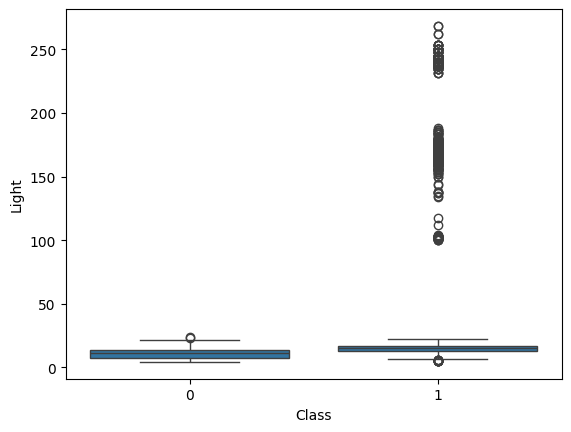

In [11]:
sns.boxplot(x='Class', y='Light', data=df_spoil)

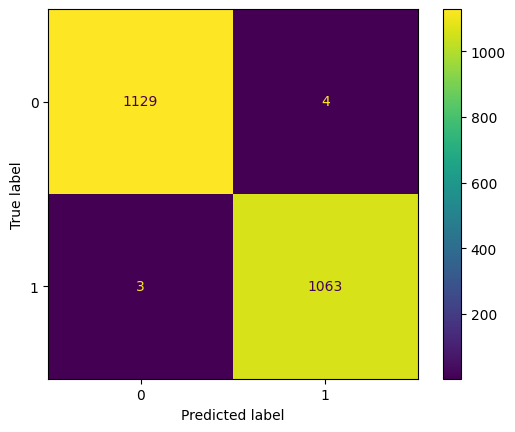

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.show()

In [13]:
# =========================
# 8. SAVE MODEL
# =========================
joblib.dump(rf, "food_spoilage_model.pkl")

print("Model saved successfully.")

Model saved successfully.
